In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

from xgboost import XGBClassifier

import joblib

In [2]:
df = pd.read_csv("customer-churn-training.csv")

df.head()

,customer_id,tenure_months,support_tickets,monthly_spend_inr,last_login_days,plan_type,churned
0,C001,2,4,499,21,Basic,1
1,C002,18,1,1299,2,Pro,0
2,C003,6,3,799,14,Basic,1
3,C004,30,0,1499,1,Pro,0
4,C005,11,2,999,5,Standard,0


In [3]:
X = df.drop(columns=["churned", "customer_id"])
y = df["churned"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 9
Testing samples: 3


In [5]:
numeric_features = [
    "tenure_months",
    "support_tickets",
    "monthly_spend_inr",
    "last_login_days"
]

categorical_features = [
    "plan_type"
]

In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

In [8]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [9]:
param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["liblinear"]
    },

    "Random Forest": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [None, 3, 5],
        "model__min_samples_split": [2, 4]
    },

    "XGBoost": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"]
    }
}

In [10]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [11]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_results = {}
best_models = {}

for name in pipelines:

    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        estimator=pipelines[name],
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    grid_results[name] = grid
    best_models[name] = grid.best_estimator_

    print("Best parameters:")
    print(grid.best_params_)

    print("Best CV ROC-AUC:")
    print(grid.best_score_)


Tuning Logistic Regression...
Best parameters:
{'model__C': 0.01, 'model__solver': 'liblinear'}
Best CV ROC-AUC:
1.0

Tuning Random Forest...
Best parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV ROC-AUC:
1.0

Tuning XGBoost...
Best parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 50}
Best CV ROC-AUC:
0.5

Tuning SVM...
Best parameters:
{'model__C': 0.1, 'model__kernel': 'linear'}
Best CV ROC-AUC:
1.0


In [12]:
results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_prob
        )
    })

In [13]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.5,1.0,0.666667,1.0
1,Random Forest,1.0,1.0,1.000000,1.0
3,SVM,1.0,1.0,1.000000,1.0
2,XGBoost,0.0,0.0,0.000000,0.5


In [14]:
champion_name = results_df.iloc[0]["Model"]

champion_model = best_models[champion_name]

print("Champion Model:", champion_name)

Champion Model: Logistic Regression


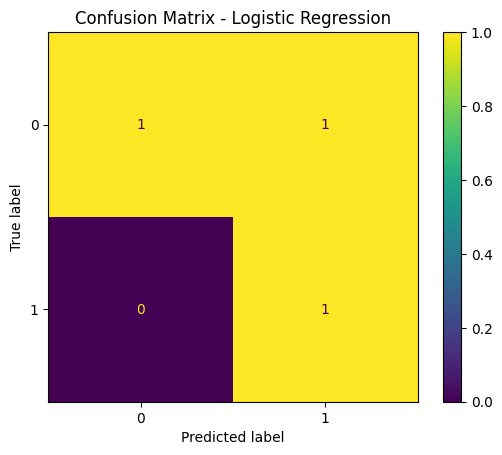

In [15]:
y_pred_champion = champion_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_champion
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    f"Confusion Matrix - {champion_name}"
)

plt.show()

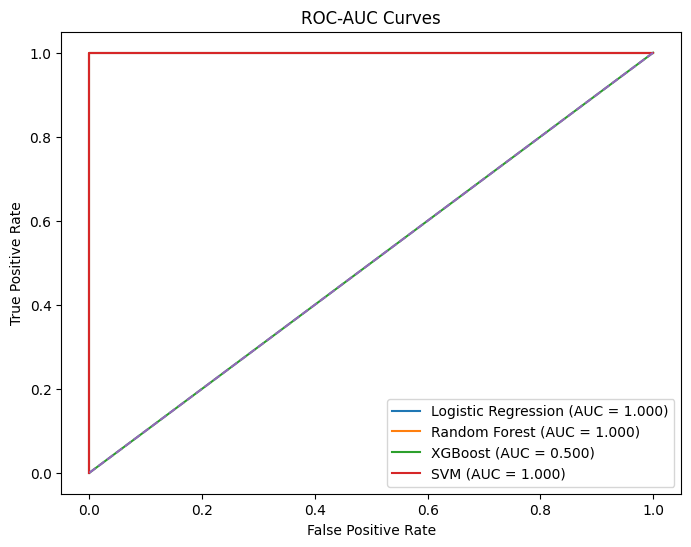

In [16]:
plt.figure(figsize=(8, 6))

for name, model in best_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curves")

plt.legend()

plt.show()

In [17]:
joblib.dump(
    champion_model,
    "champion_model.joblib"
)

print("Champion model saved successfully.")

Champion model saved successfully.


In [18]:
loaded_model = joblib.load(
    "champion_model.joblib"
)

predictions = loaded_model.predict(X_test)

print(predictions)

[1 1 0]


## Dataset Limitation

This dataset contains only 12 observations. Therefore, model performance
metrics and hyperparameter-selection results are highly sensitive to the
train-test split and should not be interpreted as evidence of real-world
generalization.

The purpose of this implementation is to demonstrate the complete
classification modeling, hyperparameter tuning, evaluation, and model
serialization workflow.